## CMPINF 2100 Week 08

### KMeans with 2 variables

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

## Read Data

In [2]:
df = pd.read_csv('cluster_2_variables_example.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   x1          300 non-null    float64
 1   x2          300 non-null    float64
 2   true_group  300 non-null    object 
dtypes: float64(2), object(1)
memory usage: 7.2+ KB


In [5]:
df.dtypes

x1            float64
x2            float64
true_group     object
dtype: object

In [6]:
df.isna().sum()

x1            0
x2            0
true_group    0
dtype: int64

In [7]:
df.nunique()

x1            300
x2            300
true_group      5
dtype: int64

In [8]:
df.true_group.value_counts()

true_group
A    60
E    60
D    60
B    60
C    60
Name: count, dtype: int64

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


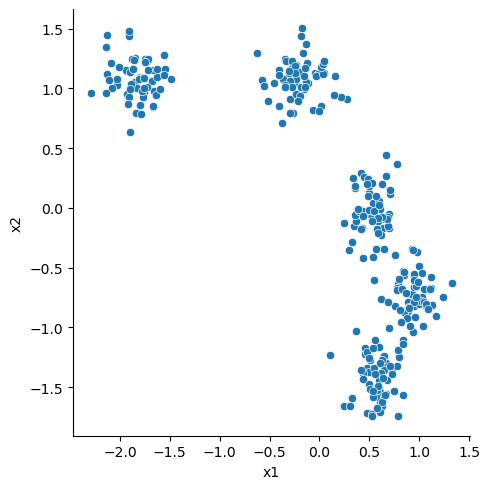

In [10]:
sns.relplot( data = df, x='x1', y='x2')
plt.show()

Color by the TRUE KNOWN groupings

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


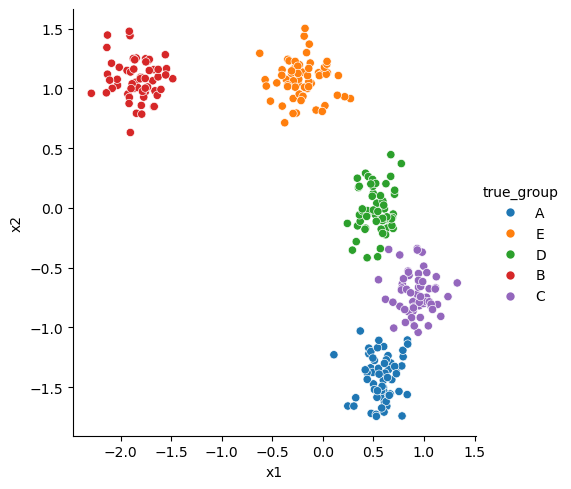

In [11]:
sns.relplot(data = df, x='x1', y='x2', hue='true_group')
plt.show()

## KMeans
Let's prepare the data as  required by scikit-learn

In [12]:
X = df.select_dtypes('number').copy().to_numpy()

In [13]:
X.shape

(300, 2)

In [14]:
from sklearn.cluster import KMeans

INITIALIZE, FIT, and PREDICT!!!

Let's do all actions in a single line of code!!

We know there are 5 groupings, so let's use 5 clusters

In [15]:
clusters_5 = KMeans(n_clusters=5, random_state=121, n_init=25, max_iter=500).fit_predict( X )

Now, assign the CLUSTER LABELS to a copied DataFrame.

In [19]:
df_copy = df.copy()

In [20]:
df_copy['k5'] = pd.Series(clusters_5, index=df_copy.index).astype('category')

In [21]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   x1          300 non-null    float64 
 1   x2          300 non-null    float64 
 2   true_group  300 non-null    object  
 3   k5          300 non-null    category
dtypes: category(1), float64(2), object(1)
memory usage: 7.6+ KB


In [22]:
df_copy.nunique()

x1            300
x2            300
true_group      5
k5              5
dtype: int64

In [23]:
df_copy.k5.value_counts()

k5
3    61
0    60
1    60
2    60
4    59
Name: count, dtype: int64

In [25]:
df_copy.true_group.value_counts()

true_group
A    60
E    60
D    60
B    60
C    60
Name: count, dtype: int64

Let's visualize the cluster results on a scatter plot

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


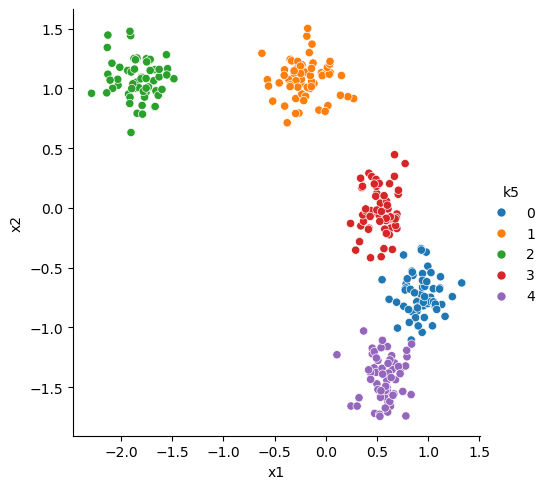

In [26]:
sns.relplot( data = df_copy, x='x1', y='x2', hue='k5')
plt.show()

Let's use a HEAT MAP to COMPARE the cluster labels with the KNOWN true groupings!!

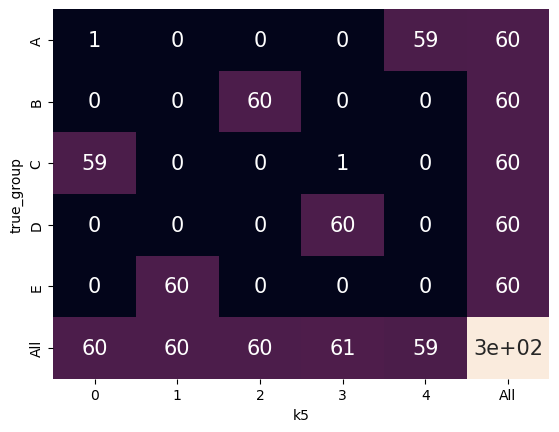

In [27]:
fig, ax = plt.subplots()
sns.heatmap( data = pd.crosstab( df_copy.true_group, df_copy.k5, margins=True),
            annot=True, annot_kws={'fontsize':15},
            cbar=False,
           ax=ax)
plt.show()

Let's use the MARKER SHAPE via the style argument in `sns.relplot()` to check which specific data points are mis labeled

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


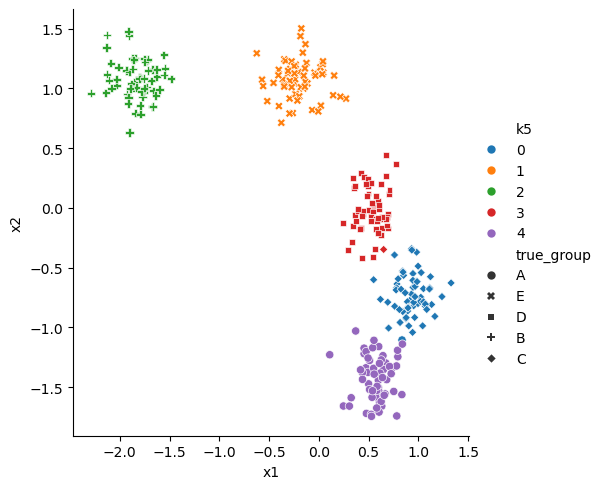

In [28]:
sns.relplot( data = df_copy, x='x1', y='x2', hue='k5', style='true_group')
plt.show()

KMeans has NO KNOWLEDGE of the groupings! It's clustering ONLY based on teh numeric columns!!!

## What if we did NOT know the number of clusters to try?

Always start with 2 clusters to see what happens

In [29]:
clusters_2 = KMeans(n_clusters=2, random_state=121, n_init=25, max_iter=500).fit_predict( X )

In [30]:
df_copy['k2'] = pd.Series( clusters_2, index=df_copy.index ).astype('category')

In [31]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   x1          300 non-null    float64 
 1   x2          300 non-null    float64 
 2   true_group  300 non-null    object  
 3   k5          300 non-null    category
 4   k2          300 non-null    category
dtypes: category(2), float64(2), object(1)
memory usage: 8.0+ KB


In [32]:
df_copy.k2.value_counts()

k2
0    180
1    120
Name: count, dtype: int64

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


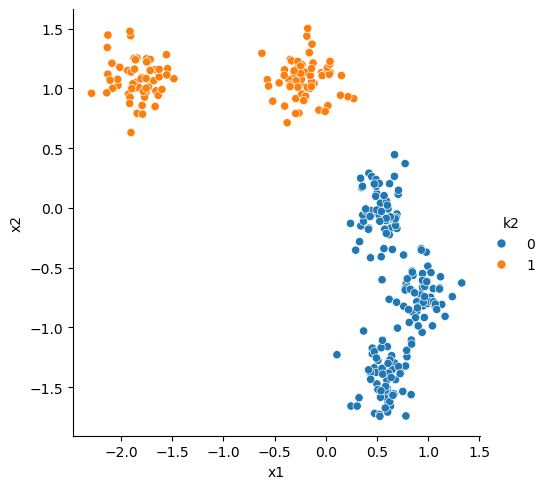

In [33]:
sns.relplot( data = df_copy, x='x1', y='x2', hue='k2')
plt.show()

## Optimal number of clusters
You do not need to manually try out many different number of clusters

Try 2 clusters. Then try one more representative number based on you exploration OR based on some known grouping

Then  use KNEE BEND plot to figure out a "better" number of clusters

In [34]:
tots_within = []

K = range(1, 31)

for k in K:
    km = KMeans(n_clusters=k, random_state=121, n_init=25, max_iter=500)
    km = km.fit( X )
    tots_within.append( km.inertia_) 

In [35]:
tots_within

[600.0,
 161.38468374420995,
 80.13907651723633,
 32.7368903265473,
 15.869535730997766,
 14.318852776093745,
 12.884487364117241,
 11.544412864887178,
 10.439667115941155,
 9.28117175028779,
 8.693931900596077,
 7.96722654783067,
 7.5020953843245,
 6.98632171108637,
 6.544171245944585,
 6.115005262502656,
 5.841992376076675,
 5.506056444478336,
 5.205443919900853,
 4.936052847205938,
 4.696629038577141,
 4.429463318042978,
 4.23031556678751,
 4.1236991553782,
 3.87701209339164,
 3.7513061172134106,
 3.555140177486473,
 3.437673067489185,
 3.264680807772013,
 3.100533952239463]

Visualize the KNEE BEND plot as a line chart

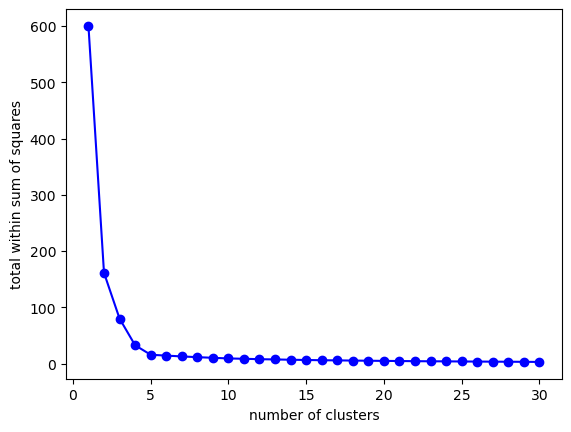

In [36]:
fig, ax = plt.subplots()

ax.plot( K, tots_within, 'bo-')
ax.set_xlabel('number of clusters')
ax.set_ylabel('total within sum of squares')

plt.show()